In [31]:
# ===========================================
# Zelle 1: Imports & Parameter
# ===========================================
from pathlib import Path
import pandas as pd
import numpy as np
from math import sqrt

# Basisordner anpassen: Darin liegen node-1 ... node-14 mit 01.json ... 04.json
BASE_DIR = Path("/Users/checkito744/Developer/Projects/University/Bachelorarbeit/crownet-testbed/dev/laboratory/05-09-2025/scenarios/ramp_rate/beacon")
N_NODES  = 14
RUNS     = ["01.json","02.json","03.json","04.json"]

# Fenstergröße für gleitendes Mittel (in Sekunden)
ROLL_S   = 5

# Optional: Ergebnisse als CSV ablegen?
SAVE_CSV = False
OUT_CSV  = BASE_DIR / "aggregated_throughput_5s.csv"

In [32]:
# ===========================================
# Zelle 2: Daten einlesen
# ===========================================
def load_all_data(base_dir: Path, n_nodes: int, runs: list[str]) -> pd.DataFrame:
    """
    Liest alle JSON-Arrays aus node-1..node-N und Runs (01.json..)
    Rückgabe-Spalten: timestamp (UTC), sizeBytes, node, run
    """
    frames = []
    for node_id in range(1, n_nodes + 1):
        node_dir = base_dir / f"node-{node_id}"
        for run in runs:
            fp = node_dir / run
            df = pd.read_json(fp)
            if df.empty:
                continue
            # Timestamps sauber nach UTC konvertieren
            df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
            df = df.dropna(subset=["timestamp", "sizeBytes"])
            df["node"] = node_id
            df["run"]  = run
            frames.append(df[["timestamp", "sizeBytes", "node", "run"]])
    if not frames:
        return pd.DataFrame(columns=["timestamp","sizeBytes","node","run"])
    return pd.concat(frames, ignore_index=True).sort_values("timestamp")

df = load_all_data(BASE_DIR, N_NODES, RUNS)
print(f"Geladene Pakete: {len(df):,}")
display(df.head())

Geladene Pakete: 107,365


,timestamp,sizeBytes,node,run
0,2025-09-05 13:09:01.327000+00:00,38,1,01.json
1,2025-09-05 13:09:01.427000+00:00,38,1,01.json
2,2025-09-05 13:09:01.528000+00:00,38,1,01.json
3,2025-09-05 13:09:01.628000+00:00,38,1,01.json
4,2025-09-05 13:09:01.728000+00:00,38,1,01.json


In [33]:
# ===========================================
# Zelle 3: Runs relativ ausrichten (t = 0 am Run-Start)
# ===========================================
# Startzeit pro Run
t0_per_run = (
    df.groupby("run")["timestamp"]
      .min()
      .rename("t0")
      .to_dict()
)

# relative Sekunde als ganzzahliger Index
df["rel_sec"] = (df["timestamp"] - df["run"].map(t0_per_run)).dt.total_seconds().astype(int)
df = df[(df["rel_sec"] >= 0) & df["sizeBytes"].notna()]

print("Zeitfenster (rel. Sekunden) je Run:")
display(df.groupby("run")["rel_sec"].agg(["min","max","count"]).rename(columns={"count":"packets"}))

Zeitfenster (rel. Sekunden) je Run:


,min,max,packets
run,,,
01.json,0,559,26880
02.json,0,559,26904
03.json,0,545,26701
04.json,0,559,26880


In [34]:
# ===========================================
# Zelle 4: Bytes/s → kbit/s je Run & rel_sec, dann 5s-Rolling je Run
# ===========================================
# 1) Bytes aller Nodes pro Run und rel_sec aufsummieren
per_run_1s = (
    df.groupby(["run", "rel_sec"])["sizeBytes"]
      .sum()
      .rename("bytes_per_s")
      .reset_index()
)

# 2) Umrechnung in kbit/s
per_run_1s["kbit_per_s"] = per_run_1s["bytes_per_s"] * 8.0 / 1000.0

# 3) 5s-Rolling-Mean je Run (Basis: rel_sec als ganzzahliger Sekundenindex)
#    → wir nehmen ein fensterbasiertes Rolling (window=ROLL_S) pro Run.
per_run_1s = per_run_1s.sort_values(["run", "rel_sec"]).set_index("rel_sec")
per_run_1s["kbit_per_s_5s"] = (
    per_run_1s
    .groupby("run")["kbit_per_s"]
    .rolling(window=ROLL_S, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Kontrolle
display(per_run_1s.head(10))

,run,bytes_per_s,kbit_per_s,kbit_per_s_5s
rel_sec,,,,
0,01.json,380,3.040,3.0400
1,01.json,380,3.040,3.0400
2,01.json,380,3.040,3.0400
3,01.json,380,3.040,3.0400
4,01.json,380,3.040,3.0400
5,01.json,380,3.040,3.0400
6,01.json,380,3.040,3.0400
7,01.json,380,3.040,3.0400
8,01.json,380,3.040,3.0400


In [35]:
# ===========================================
# Zelle 5: Varianz/Std zwischen Runs pro Sekunde (auf 5s-Basis)
# ===========================================
# Pivot: Zeilen = rel_sec, Spalten = Run, Werte = 5s-Mittel (kbit/s)
wide_5s = per_run_1s.reset_index().pivot(index="rel_sec", columns="run", values="kbit_per_s_5s")

# Mittelwert & Std-Abweichung über die 4 Runs pro rel_sec
mean_per_sec = wide_5s.mean(axis=1, skipna=True)
std_per_sec  = wide_5s.std(axis=1, ddof=1, skipna=True)  # ddof=1 → Stichproben-Std
var_per_sec  = wide_5s.var(axis=1, ddof=1, skipna=True)

# Zusammenführen für Export/Anzeige
summary_per_sec = pd.DataFrame({
    "rel_sec": mean_per_sec.index,
    "mean_kbit_s_5s": mean_per_sec.values,
    "std_kbit_s_5s": std_per_sec.values,
    "var_kbit_s_5s": var_per_sec.values,
}).set_index("rel_sec")

print("Beispiel (erste 10 Sekunden):")
display(summary_per_sec.head(10))

# Ein paar globale Kenngrößen (optional)
time_avg_mean = float(mean_per_sec.mean())          # Zeitlicher Durchschnitt des Run-Mittels
time_avg_std  = float(std_per_sec.mean(skipna=True))# Zeitlicher Durchschnitt der Run-Std
print(f"\nZeitlicher Durchschnitt des Mittels: {time_avg_mean:,.2f} kbit/s")
print(f"Zeitlicher Durchschnitt der Std:     {time_avg_std:,.2f} kbit/s")

if SAVE_CSV:
    summary_per_sec.to_csv(OUT_MEAN_STD_CSV)
    print(f"Gespeichert: {OUT_MEAN_STD_CSV}")

Beispiel (erste 10 Sekunden):


,mean_kbit_s_5s,std_kbit_s_5s,var_kbit_s_5s
rel_sec,,,
0,3.040,0.0000,0.000000
1,3.040,0.0000,0.000000
2,3.040,0.0000,0.000000
3,3.040,0.0000,0.000000
4,3.040,0.0000,0.000000
5,3.040,0.0000,0.000000
6,3.040,0.0000,0.000000
7,3.040,0.0000,0.000000
8,3.040,0.0000,0.000000



Zeitlicher Durchschnitt des Mittels: 14.60 kbit/s
Zeitlicher Durchschnitt der Std:     0.16 kbit/s


In [36]:
# ===========================================
# Anteil pro Node am gemittelten Gesamtdurchsatz (über 4 Runs)
# Voraussetzung: df mit Spalten ['run','node','rel_sec','sizeBytes']
# ===========================================

SAVE_CSV = False
OUT_CSV  = BASE_DIR / "node_shares_bytesps_over_4_runs.csv"

# 1) Pro Sekunde und Node aggregieren (Bytes/s und Pakete/s je Run)
per_sec_node = (
    df.groupby(["run", "node", "rel_sec"])["sizeBytes"]
      .agg(bytes_s="sum", packets_s="size")
      .reset_index()
)

# 2) Je Run & Node: Mittel über alle Sekunden (ergibt mean Bytes/s pro Run+Node)
per_run_node_means = (
    per_sec_node.groupby(["run", "node"])
    .agg(mean_bytes_s=("bytes_s", "mean"),
         mean_pkts_s =("packets_s","mean"))
    .reset_index()
)

# 3) Über Runs mitteln (→ pro Node mittlere Bytes/s über 4 Runs) + Std über Runs
per_node_across_runs = (
    per_run_node_means.groupby("node")
    .agg(mean_bytes_s=("mean_bytes_s","mean"),
         std_bytes_s =("mean_bytes_s","std"),
         mean_pkts_s =("mean_pkts_s","mean"),
         std_pkts_s  =("mean_pkts_s","std"))
    .reset_index()
)

# 4) Anteil am Gesamtdurchsatz (auf Basis der mittleren Bytes/s)
total_mean_bytes = per_node_across_runs["mean_bytes_s"].sum()
per_node_across_runs["share_percent"] = (
    100.0 * per_node_across_runs["mean_bytes_s"] / total_mean_bytes
    if total_mean_bytes > 0 else 0.0
)

# 5) Hübsch machen, sortieren, runden
tbl = (
    per_node_across_runs
    .sort_values("node")
    .rename(columns={
        "node": "Node",
        "mean_pkts_s": "Mittel Pakete/s",
        "std_pkts_s":  "Std Pakete/s",
        "mean_bytes_s":"Mittel Bytes/s",
        "std_bytes_s": "Std Bytes/s",
        "share_percent":"Anteil am Gesamtdurchsatz (%)"
    })
)

tbl = tbl[["Node","Mittel Pakete/s","Std Pakete/s",
           "Mittel Bytes/s","Std Bytes/s","Anteil am Gesamtdurchsatz (%)"]]

tbl = tbl.round({
    "Mittel Pakete/s": 2,
    "Std Pakete/s": 2,
    "Mittel Bytes/s": 2,
    "Std Bytes/s": 2,
    "Anteil am Gesamtdurchsatz (%)": 2
})

display(tbl)

if SAVE_CSV:
    tbl.to_csv(OUT_CSV, index=False)
    print(f"[OK] gespeichert: {OUT_CSV}")

,Node,Mittel Pakete/s,Std Pakete/s,Mittel Bytes/s,Std Bytes/s,Anteil am Gesamtdurchsatz (%)
0,1,4.84,0.02,184.03,0.81,7.77
1,2,4.72,0.01,179.29,0.46,7.57
2,3,4.58,0.01,174.14,0.42,7.35
3,4,4.46,0.01,169.48,0.26,7.15
4,5,4.35,0.02,165.36,0.78,6.98
5,6,4.24,0.02,161.24,0.90,6.81
6,7,4.19,0.01,159.19,0.23,6.72
7,8,4.18,0.03,158.72,1.20,6.70
8,9,4.21,0.02,159.98,0.58,6.75
9,10,4.29,0.01,163.15,0.33,6.89


[OK] Plot gespeichert: plots/burst_message+rate_no_nodes.pdf


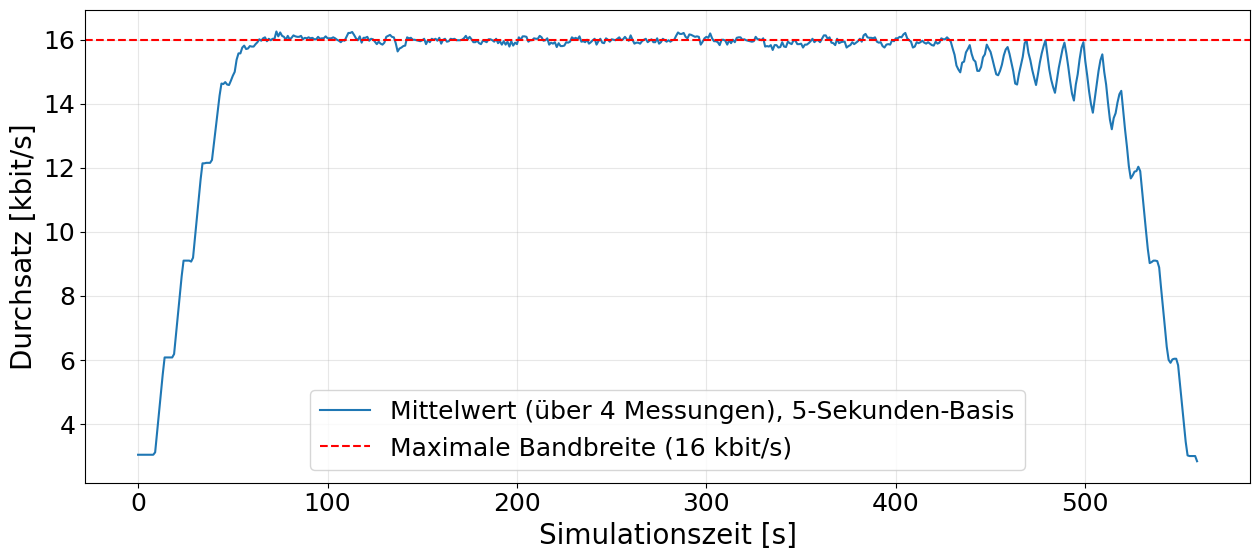

In [37]:
# ===========================================
# Zelle 6: Durchsatz (kbit/s) + aktiver-Knoten-Plot (5s-Regel)
# ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Schriftgrößen global anpassen ----------
plt.rcParams.update({
    "font.size": 20,           # Grundschriftgröße
    "axes.titlesize": 22,      # Titel Achsen
    "axes.labelsize": 20,      # Achsenbeschriftung
    "xtick.labelsize": 18,     # X-Ticks
    "ytick.labelsize": 18,     # Y-Ticks
    "legend.fontsize": 18      # Legende
})

# ---------- Steuerungsvariable ----------
SHOW_ACTIVE_NODES = False  # True = unteren Plot anzeigen, False = nur Durchsatz-Plot

# ---------- Parameter für maximale Bandbreite (kbit/s) ----------
MAX_BANDWIDTH_KBIT = 16  

# ---------- Aktive Knoten berechnen (5s-Fenster) ----------
ROLL_WINDOW = 5  # Sekunden

per_node_sec = (
    df.groupby(["rel_sec", "node"])["sizeBytes"]
      .sum()
      .reset_index()
)
wide_node = per_node_sec.pivot(index="rel_sec", columns="node", values="sizeBytes").fillna(0)
active_now = (wide_node > 0).astype(int)
active_last5s = active_now.rolling(window=ROLL_WINDOW, min_periods=1).max()
active_count = active_last5s.sum(axis=1)

# ---------- Figure erstellen ----------
if SHOW_ACTIVE_NODES:
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(13, 9), sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1]}
    )
else:
    fig, ax1 = plt.subplots(1, 1, figsize=(13, 6))
    ax2 = None

# --- Oberer Plot: Mittelkurve in kbit/s ---
ax1.plot(mean_per_sec.index, mean_per_sec.values,
         label="Mittelwert (über 4 Messungen), 5-Sekunden-Basis",
         color="C0")

# --- Rote gestrichelte Linie für maximale Bandbreite ---
ax1.axhline(MAX_BANDWIDTH_KBIT, color='red', linestyle='--',
            label=f"Maximale Bandbreite ({MAX_BANDWIDTH_KBIT} kbit/s)")

ax1.set_ylabel("Durchsatz [kbit/s]")
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- Unterer Plot: Anzahl aktiver Knoten (optional) ---
if SHOW_ACTIVE_NODES and ax2 is not None:
    ax2.step(active_count.index, active_count.values, where="post",
             label=f"Aktive Knoten (in den letzten {ROLL_WINDOW} Sekunden)")
    ax2.set_ylim(0, 16)
    ax2.set_yticks(range(0, 17, 4))
    ax2.set_xlabel("Simulationszeit [s]")
    ax2.set_ylabel("Anzahl aktiver Knoten")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
else:
    ax1.set_xlabel("Simulationszeit [s]")  # nur obere Achse hat X-Beschriftung

plt.tight_layout()

plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)
suffix = "_with_nodes" if SHOW_ACTIVE_NODES else "_no_nodes"
out_file = plots_dir / f"burst_message+rate{suffix}.pdf"
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f"[OK] Plot gespeichert: {out_file}")

plt.show()

Gesamt geladene SENT-Pakete: 277,387


,timestamp,sizeBytes,scenario,run,node
0,2025-09-05 12:20:39.113000+00:00,1400,always_rate,01.json,1
1,2025-09-05 12:20:39.270000+00:00,1400,always_rate,01.json,1
2,2025-09-05 12:20:39.457000+00:00,1400,always_rate,01.json,1
3,2025-09-05 12:20:39.733000+00:00,1400,always_rate,01.json,1
4,2025-09-05 12:20:40.012000+00:00,1400,always_rate,01.json,1


,scenario,run,bytes_sent,packets_sent
0,always_rate,01.json,34834800,24882
1,always_rate,02.json,34900600,24929
2,always_rate,03.json,34900600,24929
3,always_rate,04.json,34897800,24927
4,burst_rate,01.json,29895600,21354
5,burst_rate,02.json,29885800,21347
6,burst_rate,03.json,29971200,21408
7,burst_rate,04.json,29940400,21386
8,ramp_rate,01.json,32375000,23125
9,ramp_rate,02.json,32278400,23056



=== Durchsatzanalyse (GESENDET) – je Szenario, ddof=0 ===
  Szenario  Wiederholungen  Mittel Pakete gesendet  Std Pakete gesendet  Mittel Bytes gesendet  Std Bytes gesendet
Szenario 1               4                24916.75            20.079529             34883450.0        28111.341128
Szenario 2               4                23056.25            71.625327             32278750.0       100275.458114
Szenario 3               4                21373.75            24.641175             29923250.0        34497.644847


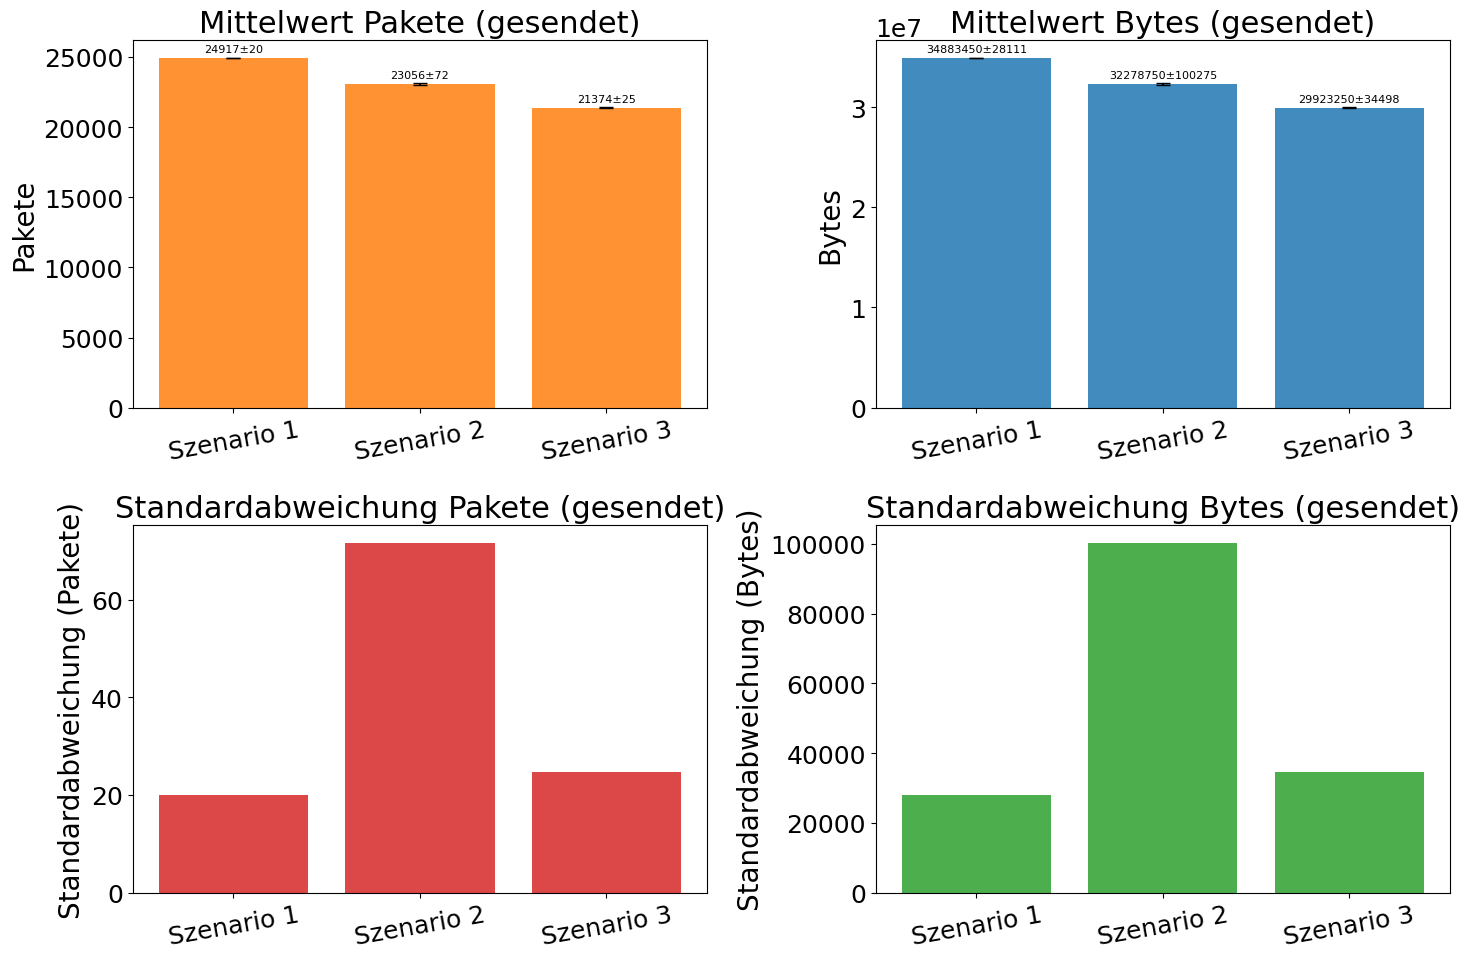

,Szenario,Wiederholungen,Mittel Pakete gesendet,Std Pakete gesendet,Mittel Bytes gesendet,Std Bytes gesendet
0,Szenario 1,4,24916.75,20.079529,34883450.0,28111.341128
1,Szenario 2,4,23056.25,71.625327,32278750.0,100275.458114
2,Szenario 3,4,21373.75,24.641175,29923250.0,34497.644847


In [38]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path("/Users/checkito744/Developer/Projects/University/Bachelorarbeit/crownet-testbed/dev/laboratory/05-09-2025/scenarios")
CONFIG_DIRS = [
    BASE / "always_rate" / "message",  
    BASE / "ramp_rate"   / "message",  
    BASE / "burst_rate"  / "message",  
]

RUN_FILES = ["01.json","02.json","03.json","04.json"]
N_NODES   = 14

NODE_FILTER = None  

def load_sent_dataframe(config_dir: Path, n_nodes: int, run_files, node_filter=None) -> pd.DataFrame:
    """
    Lädt SENT-Logs aus einem Szenario-Ordner (…/<scenario>/beacon).
    Gibt Spalten zurück: ['scenario','run','node','timestamp','sizeBytes']
    """
    frames = []
    scenario_name = config_dir.parent.name  # Ordner über 'beacon' = Szenarioname

    for node_id in range(1, n_nodes + 1):
        if node_filter is not None and node_id != node_filter:
            continue
        node_dir = config_dir / f"node-{node_id}"
        if not node_dir.exists():
            continue

        for run in run_files:
            fp = node_dir / run
            if not fp.exists():
                continue
            try:
                df = pd.read_json(fp)
            except Exception:
                continue
            if df.empty or "sizeBytes" not in df.columns:
                continue

            # Timestamp optional normalisieren (für Totals nicht zwingend)
            if "timestamp" in df.columns:
                df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
            else:
                df["timestamp"] = pd.NaT

            out = df[["timestamp","sizeBytes"]].copy()
            out["scenario"] = scenario_name
            out["run"]      = run
            out["node"]     = node_id
            frames.append(out)

    if not frames:
        return pd.DataFrame(columns=["scenario","run","node","timestamp","sizeBytes"])
    return pd.concat(frames, ignore_index=True)

# ---- Laden aller drei Szenarien ----
all_cfg = []
for cfg_dir in CONFIG_DIRS:
    all_cfg.append(load_sent_dataframe(cfg_dir, N_NODES, RUN_FILES, NODE_FILTER))
df = pd.concat(all_cfg, ignore_index=True) if all_cfg else pd.DataFrame(columns=["scenario","run","node","timestamp","sizeBytes"])

print(f"Gesamt geladene SENT-Pakete: {len(df):,}")
display(df.head())

# ---- Totals pro (Szenario, Run) ----
per_run_sent = (
    df.groupby(["scenario","run"], as_index=False)
      .agg(bytes_sent=("sizeBytes","sum"),
           packets_sent=("sizeBytes","size"))
)
display(per_run_sent)

# ---- Statistik je Szenario über die Runs (ddof=0) ----
rows = []
for scen, grp in per_run_sent.groupby("scenario"):
    b = grp["bytes_sent"].to_numpy()
    p = grp["packets_sent"].to_numpy()
    rows.append({
        "Szenario": scen,
        "Wiederholungen": int(len(grp)),
        "Mittel Pakete gesendet":   float(np.mean(p)),
        "Std Pakete gesendet":      float(np.std(p)),   # ddof=0
        "Mittel Bytes gesendet":    float(np.mean(b)),
        "Std Bytes gesendet":       float(np.std(b)),   # ddof=0
    })

stats = pd.DataFrame(rows).sort_values("Szenario").reset_index(drop=True)

# ---- Szenario-Labels auf "Szenario 1/2/3" mappen + Reihenfolge sichern ----
rename_map = {
    "always_rate": "Szenario 1",
    "ramp_rate":   "Szenario 2",
    "burst_rate":  "Szenario 3",
}
stats["Szenario"] = stats["Szenario"].replace(rename_map)
order = ["Szenario 1","Szenario 2","Szenario 3"]
stats = stats.set_index("Szenario").loc[order].reset_index()

print("\n=== Durchsatzanalyse (GESENDET) – je Szenario, ddof=0 ===")
print(stats.to_string(index=False))

# ---- 2x2 Subplots mit je 3 Bars (ein Balken pro Szenario) ----
labels = stats["Szenario"].tolist()
mean_pkts = stats["Mittel Pakete gesendet"].to_numpy()
std_pkts  = stats["Std Pakete gesendet"].to_numpy()
mean_bytes= stats["Mittel Bytes gesendet"].to_numpy()
std_bytes = stats["Std Bytes gesendet"].to_numpy()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# (1) Mittelwert Pakete gesendet
bars1 = ax1.bar(labels, mean_pkts, yerr=std_pkts, capsize=5, alpha=0.85, color="tab:orange")
ax1.set_title("Mittelwert Pakete (gesendet)")
ax1.set_ylabel("Pakete")
ax1.tick_params(axis="x", rotation=10)
for bar, m, sdev in zip(bars1, mean_pkts, std_pkts):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + sdev + max(1.0, m*0.01),
             f"{m:.0f}±{sdev:.0f}", ha="center", va="bottom", fontsize=8)

# (2) Mittelwert Bytes gesendet
bars2 = ax2.bar(labels, mean_bytes, yerr=std_bytes, capsize=5, alpha=0.85, color="tab:blue")
ax2.set_title("Mittelwert Bytes (gesendet)")
ax2.set_ylabel("Bytes")
ax2.tick_params(axis="x", rotation=10)
for bar, m, sdev in zip(bars2, mean_bytes, std_bytes):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + sdev + max(1.0, m*0.01),
             f"{m:.0f}±{sdev:.0f}", ha="center", va="bottom", fontsize=8)

# (3) Standardabweichung Pakete gesendet (nur Std)
ax3.bar(labels, std_pkts, alpha=0.85, color="tab:red")
ax3.set_title("Standardabweichung Pakete (gesendet)")
ax3.set_ylabel("Standardabweichung (Pakete)")
ax3.tick_params(axis="x", rotation=10)

# (4) Standardabweichung Bytes gesendet (nur Std)
ax4.bar(labels, std_bytes, alpha=0.85, color="tab:green")
ax4.set_title("Standardabweichung Bytes (gesendet)")
ax4.set_ylabel("Standardabweichung (Bytes)")
ax4.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig("throughput_sent_szenario123.png", dpi=300, bbox_inches="tight")
plt.savefig("throughput_sent_szenario123.pdf", bbox_inches="tight")
plt.show()

# ---- Tabelle anzeigen/optional speichern ----
display(stats)
# stats.to_csv("throughput_sent_szenario123_stats.csv", index=False)